# Cleaning the day data


## Importing packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itables import show #this is for displaying dataframes in a more interactive way in Jupyter notebooks
import sys
sys.path.append("..")
from src.utils import plot_missing, detect_outliers_iqr

plt.style.use("seaborn-v0_8-whitegrid")

# Load and check it out

In [3]:
df_day = pd.read_csv("../data/raw/day.csv")
df_day.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


In [15]:
#show(df_day)
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


# Duplicated values 

For checking duplicated values we can use: 
- .duplicated()

In [ ]:
#first we can check if any rows are fully duplicated
df_day.duplicated().sum()
#then we can check if some rows are duplicated due to the combination of some columns
#df.day.duplicated(subset=["col1","col2"]).sum()
#actually this makes no sense here, does it? 

np.int64(0)

# Missing values

For missing values we can use: 

- plot_missing(df)
- df.isnull().sum()
- df.isnull().mean()

In [9]:
plot_missing(df_day)

No missing values.


# Data Types 

We need to do two things here: 

- Convert the dteday type to date 
- Convert categorical columns to the category type 

In [12]:
df_day["dteday"] = pd.to_datetime(df_day["dteday"])
df_day["dteday"].info()

<class 'pandas.Series'>
RangeIndex: 731 entries, 0 to 730
Series name: dteday
Non-Null Count  Dtype         
--------------  -----         
731 non-null    datetime64[us]
dtypes: datetime64[us](1)
memory usage: 5.8 KB


In [14]:
categorical_day_columns = ["season","yr", "mnth", "holiday", "weekday", "workingday", "weathersit"]

for col in categorical_day_columns:
    df_day[col] = df_day[col].astype("category")

df_day.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[us]
 2   season      731 non-null    category      
 3   yr          731 non-null    category      
 4   mnth        731 non-null    category      
 5   holiday     731 non-null    category      
 6   weekday     731 non-null    category      
 7   workingday  731 non-null    category      
 8   weathersit  731 non-null    category      
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: category(7), datetime64[us](1), fl

# Outliers

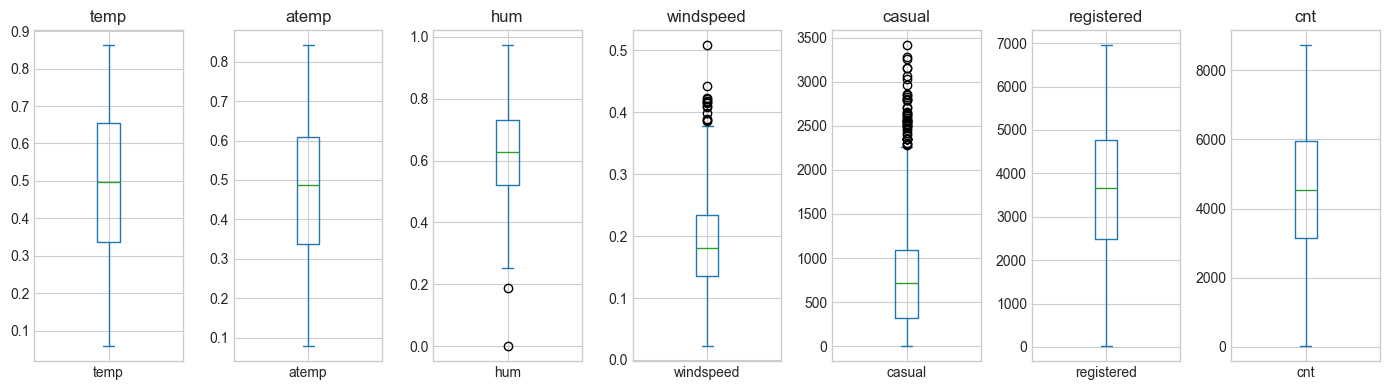

In [20]:
num_cols = ["temp", "atemp", "hum", "windspeed","casual","registered","cnt"]
fig, axes = plt.subplots(1, len(num_cols), figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    df_day[col].plot(kind="box", ax=ax, title=col)
plt.tight_layout()

In [22]:
# IQR outlier flags — decide what to do with them
for col in num_cols:
    flags = detect_outliers_iqr(df_day[col])
    print(f"{col}: {flags.sum()} outliers ({flags.mean():.1%})")

temp: 0 outliers (0.0%)
atemp: 0 outliers (0.0%)
hum: 2 outliers (0.3%)
windspeed: 13 outliers (1.8%)
casual: 44 outliers (6.0%)
registered: 0 outliers (0.0%)
cnt: 0 outliers (0.0%)


# Save cleaned data

In [24]:
# TODO: after all fixes, drop the 'instant' index column and save
df_day_clean = df_day.drop(columns=["instant"])
df_day_clean.to_csv("../data/processed/day_clean.csv", index=False)
print(f"Saved {df_day_clean.shape[0]} rows to data/processed/day_clean.csv")

Saved 731 rows to data/processed/day_clean.csv
